In [ ]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


SPY = 0
SCOUT = 1
MINER = 2
SERGEANT = 3
LIEUTENANT = 4
CAPTAIN = 5
MAJOR = 6
COLONEL = 7
GENERAL = 8
MARSHAL = 9
BOMB = 10
FLAG = 11
START = 12


COUNTS = {
    SPY: 1, SCOUT: 8, MINER: 5, SERGEANT: 4, LIEUTENANT: 4,
    CAPTAIN: 4, MAJOR: 3, COLONEL: 2, GENERAL: 1, MARSHAL: 1,
    BOMB: 6, FLAG: 1
}


HUMAN_READABLE = {
    SPY: "1", SCOUT: "2", MINER: "3", SERGEANT: "4", LIEUTENANT: "5",
    CAPTAIN: "6", MAJOR: "7", COLONEL: "8", GENERAL: "9", MARSHAL: "M",
    BOMB: "B", FLAG: "F"
}


def get_mirrored(setup):
    return setup[9::-1] + setup[19:9:-1] + setup[29:19:-1] + setup[39:29:-1]


def validate_setup(setup):
    counts = COUNTS.copy()
    for piece in setup:
        if counts[piece] == 0:
            return False
        counts[piece] -= 1
    return True


def print_setup(setup):
    if setup[0] == START:
        setup = setup[1:]
    print('_  _  x  x  _  _  x  x  _  _')
    print(', '.join(HUMAN_READABLE[piece] for piece in setup[:10]))
    print(', '.join(HUMAN_READABLE[piece] for piece in setup[10:20]))
    print(', '.join(HUMAN_READABLE[piece] for piece in setup[20:30]))
    print(', '.join(HUMAN_READABLE[piece] for piece in setup[30:40]))


def read_setups(path, unique=True, num_max_setups=None, include_mirrored=False):
    setups = []
    with open(path, "r") as file:
        reader = csv.reader(file)
        for i, row in enumerate(reader):
            if i == num_max_setups:
                break
            setups.append(tuple(int(piece) for piece in row))
    if unique:
        setups = list(set(setups))
    if include_mirrored:
        setups += [get_mirrored(setup) for setup in setups]
    return setups


class SetupsDataset(Dataset):

    def __init__(self, setups):
        self.setups = [np.array((START,) + setup) for setup in setups]
        self.id_matrix = torch.eye(13)

    def __getitem__(self, item):
        return self.id_matrix[self.setups[item][:-1]], self.setups[item][1:]

    def __len__(self):
        return len(self.setups)


class Model(nn.Module):

    def __init__(self, hidden_size=256):
        super().__init__()
        self.lstm = nn.LSTM(input_size=13, hidden_size=hidden_size,
                            num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, 12)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden


def train_single_epoch(model, dataloader, optimizer, criterion):

    model.train()
    running_loss = 0.0
    num_batches = 0

    for inputs, targets in dataloader:

        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()

        output, hidden = model.forward(inputs)

        loss = criterion(output.reshape(-1, 12), targets.reshape(-1))

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        num_batches += 1

    train_loss = running_loss / num_batches

    return train_loss


def evaluate(model, val_dataloader, criterion):

    model.eval()
    running_loss = 0.0
    num_batches = 0

    with torch.no_grad():
        for inputs, targets in val_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)

            output, hidden = model.forward(inputs)

            loss = criterion(output.reshape(-1, 12), targets.reshape(-1))

            running_loss += loss.item()

            num_batches += 1

    val_loss = running_loss / num_batches

    return val_loss


def plot_loss_curves(train_loss_per_epoch, val_loss_per_epoch, best_epoch=None):
    x_axis_values = list(range(1, len(train_loss_per_epoch) + 1))
    plt.plot(x_axis_values, train_loss_per_epoch, color="blue", label="train loss")
    plt.plot(x_axis_values, val_loss_per_epoch, color="red", label="validation loss")
    if best_epoch is not None:
        plt.axvline(x=best_epoch, linestyle="--", color="green", label="best model")
    plt.legend()
    plt.ylabel("Loss")
    plt.xlabel("Epochs")
    plt.tight_layout()
    plt.show()


def save_model(filename, model, optimizer, train_losses, val_losses, epoch):
    model_info = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'epoch': epoch,
             }
    torch.save(model_info, filename)


def generate_setup(model):
    setup = [START]
    softmax = torch.nn.functional.softmax
    counts = COUNTS.copy()
    distributions = []
    id_matrix = torch.eye(13)
    hidden = None
    for i in range(40):
        out, hidden = model.forward(
               id_matrix[np.array(setup[-1]).reshape(-1, 1)], hidden)
        out = out.squeeze()
        for piece, count in counts.items():
            if count == 0:
                out[piece] = float('-inf')
        distribution = softmax(out, dim=0)
        distributions.append(distribution)
        next_piece = torch.multinomial(distribution, 1).item()
        counts[next_piece] -= 1
        setup.append(next_piece)

    return setup, distributions

In [ ]:
all_setups = read_setups("setups.csv", num_max_setups=None, include_mirrored=True)
train_data, val_data = train_test_split(all_setups, train_size=0.85)

train_dataset = SetupsDataset(train_data)
val_dataset = SetupsDataset(val_data)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=True)

model = Model().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion =  nn.CrossEntropyLoss()
num_epochs = 50

In [ ]:
train_loss_per_epoch = []
val_loss_per_epoch = []
min_val_loss = float('inf')
best_epoch = -1

for epoch in range(1, num_epochs + 1):
    train_loss = train_single_epoch(
                   model, train_dataloader, optimizer, criterion)
    val_loss = evaluate(model, val_dataloader, criterion)
    print(f"Epoch: {epoch}, Train Loss: {round(train_loss, 3)}, "
          f"Val Loss: {round(val_loss, 3)}")
    train_loss_per_epoch.append(train_loss)
    val_loss_per_epoch.append(val_loss)
    if val_loss < min_val_loss:
        min_val_loss = val_loss
        best_epoch = epoch
        save_model("model.pth", model, optimizer, train_loss_per_epoch,
                   val_loss_per_epoch, epoch)


model = model.cpu()


Epoch: 1, Train Loss: 1.919, Val Loss: 1.76
Epoch: 2, Train Loss: 1.702, Val Loss: 1.672
Epoch: 3, Train Loss: 1.65, Val Loss: 1.635
Epoch: 4, Train Loss: 1.617, Val Loss: 1.61
Epoch: 5, Train Loss: 1.593, Val Loss: 1.588
Epoch: 6, Train Loss: 1.574, Val Loss: 1.577
Epoch: 7, Train Loss: 1.558, Val Loss: 1.558
Epoch: 8, Train Loss: 1.545, Val Loss: 1.548
Epoch: 9, Train Loss: 1.533, Val Loss: 1.541
Epoch: 10, Train Loss: 1.522, Val Loss: 1.535
Epoch: 11, Train Loss: 1.514, Val Loss: 1.527
Epoch: 12, Train Loss: 1.504, Val Loss: 1.52
Epoch: 13, Train Loss: 1.501, Val Loss: 1.518
Epoch: 14, Train Loss: 1.49, Val Loss: 1.514
Epoch: 15, Train Loss: 1.486, Val Loss: 1.51
Epoch: 16, Train Loss: 1.478, Val Loss: 1.51
Epoch: 17, Train Loss: 1.473, Val Loss: 1.505
Epoch: 18, Train Loss: 1.468, Val Loss: 1.504
Epoch: 19, Train Loss: 1.464, Val Loss: 1.501
Epoch: 20, Train Loss: 1.46, Val Loss: 1.498
Epoch: 21, Train Loss: 1.472, Val Loss: 1.522
Epoch: 22, Train Loss: 1.458, Val Loss: 1.496
Epoch

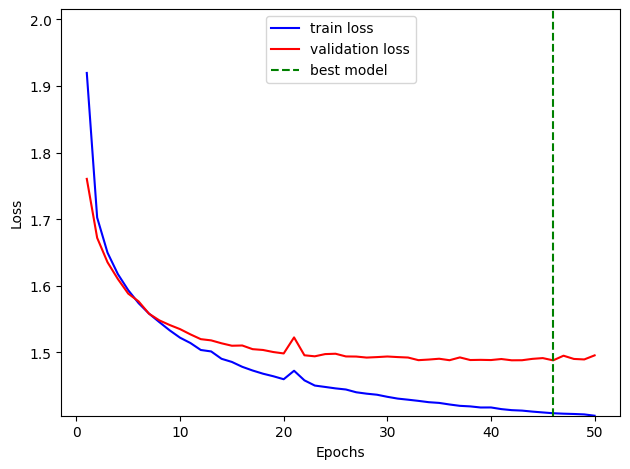

In [ ]:
plot_loss_curves(train_loss_per_epoch, val_loss_per_epoch, best_epoch)

In [ ]:
saved_model = torch.load("model.pth")

model = Model()
model.load_state_dict(saved_model['model_state_dict'])

<All keys matched successfully>

In [ ]:
generated_setup, distributions = generate_setup(model)
print_setup(generated_setup)

_  _  x  x  _  _  x  x  _  _
4, 6, 5, 6, 4, 4, 9, 6, 5, 4
2, 8, M, 7, 2, 2, 2, 1, 8, 2
2, 2, 7, B, B, B, 7, 3, 2, 3
6, 3, B, F, B, 5, B, 3, 5, 3


In [ ]:
setup, distributions = generate_setup(model)
print_setup(setup)

similarities = [(setup == s).sum() - 1 for s in train_dataset.setups]

max_similarity = max(similarities)
print(f"max similarity with training set {max_similarity}")

avg_similarity = sum(similarities) / len(similarities)
print(f"avg similarity with training set {round(avg_similarity, 3)}")

_  _  x  x  _  _  x  x  _  _
5, 6, 2, 2, 6, 7, 2, 6, 7, 5
2, 3, B, 8, 2, M, 5, 1, 9, 2
2, 2, 3, B, 3, 7, 5, 4, B, 3
8, 6, B, 4, F, B, 4, 3, 4, B
max similarity with training set 20
avg similarity with training set 5.448


_  _  x  x  _  _  x  x  _  _






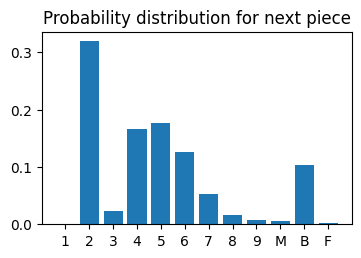

_  _  x  x  _  _  x  x  _  _
2





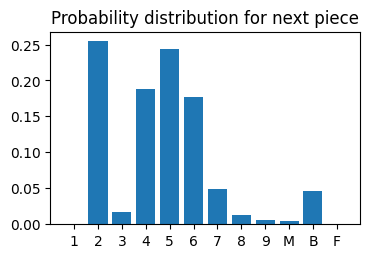

_  _  x  x  _  _  x  x  _  _
2, 2





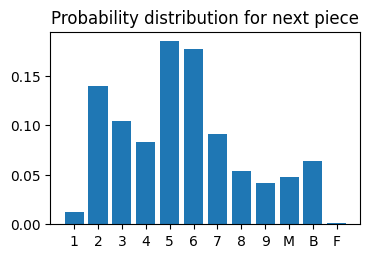

_  _  x  x  _  _  x  x  _  _
2, 2, 6





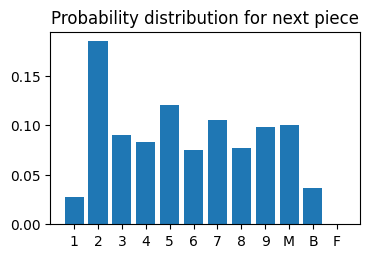

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4





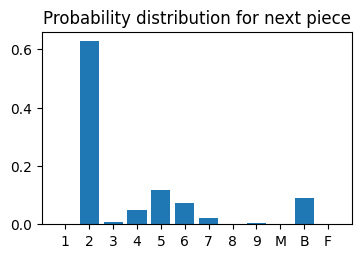

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2





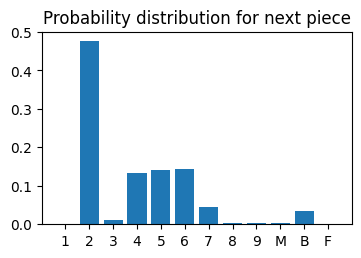

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6





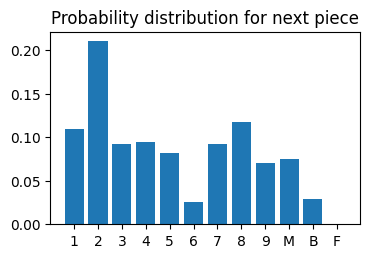

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1





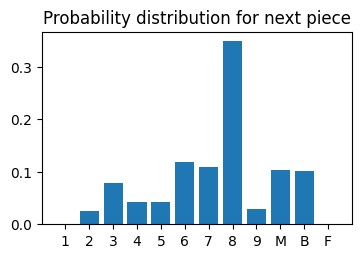

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8





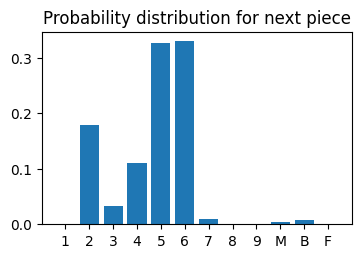

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5





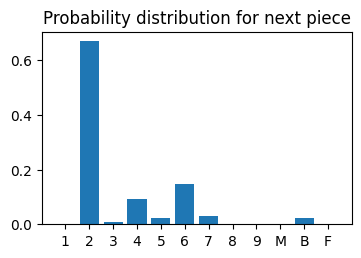

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2





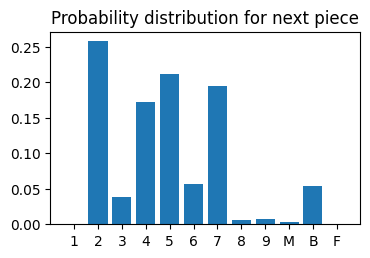

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2




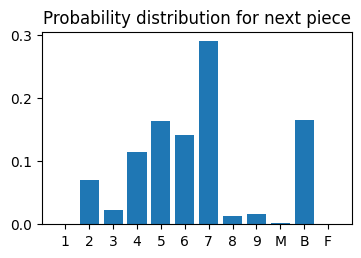

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7




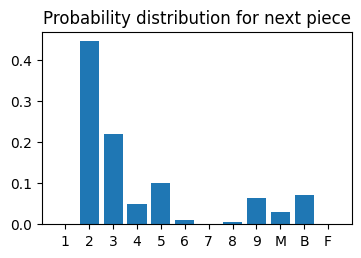

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8




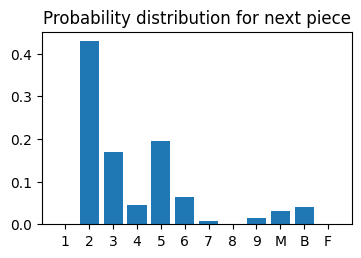

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2




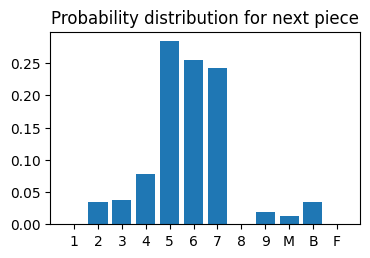

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7




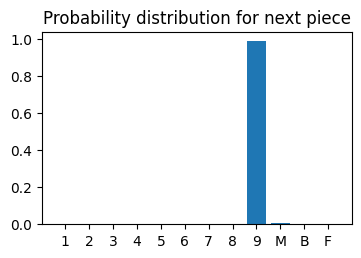

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9




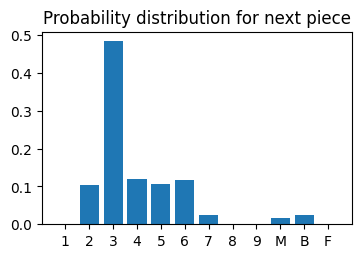

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2




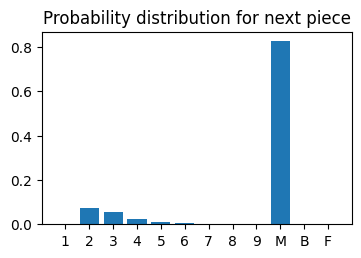

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M




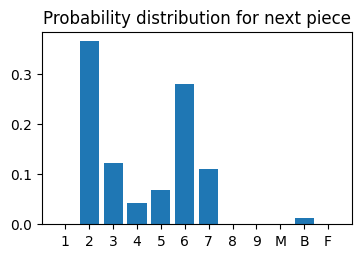

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2




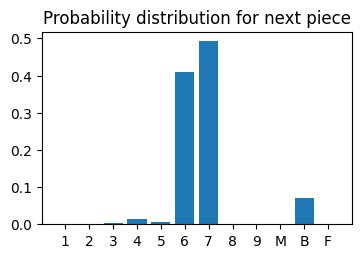

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7




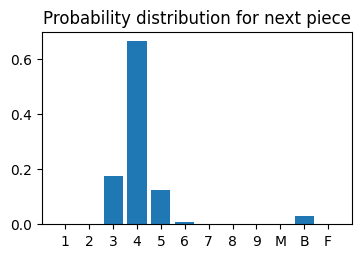

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4



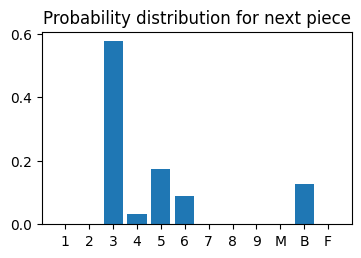

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B



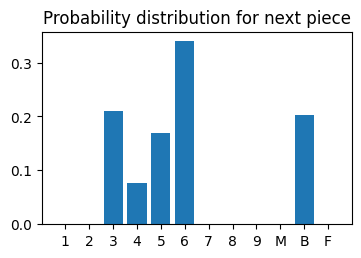

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B



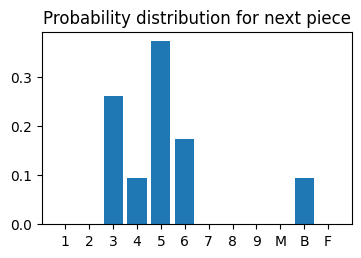

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B, 6



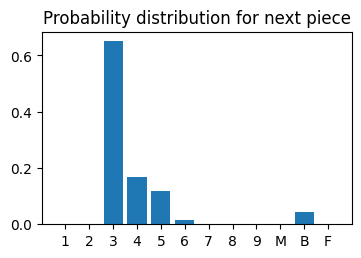

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B, 6, B



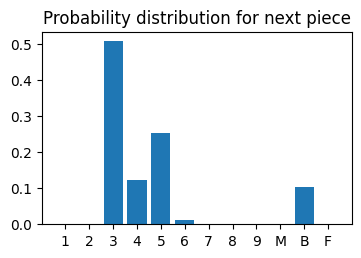

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B, 6, B, 3



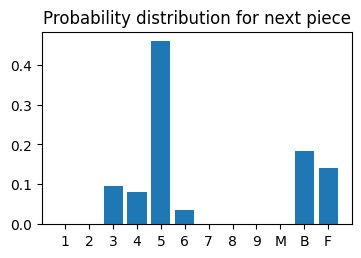

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B, 6, B, 3, 4



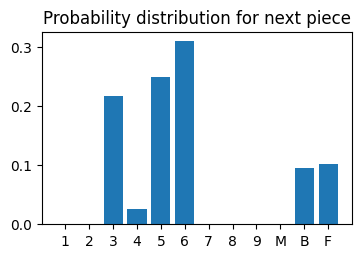

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B, 6, B, 3, 4, 3



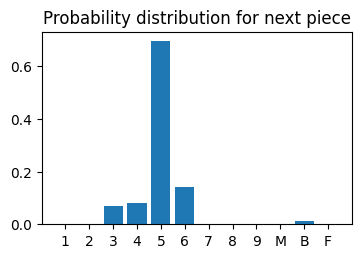

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B, 6, B, 3, 4, 3, 5



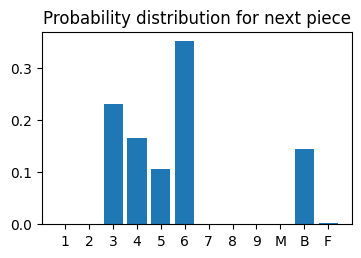

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B, 6, B, 3, 4, 3, 5, 6



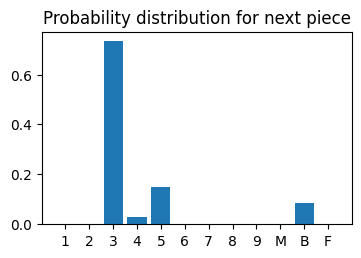

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B, 6, B, 3, 4, 3, 5, 6
3


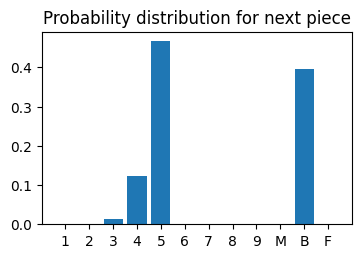

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B, 6, B, 3, 4, 3, 5, 6
3, 5


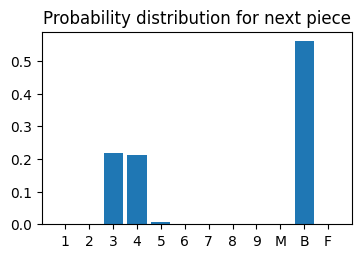

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B, 6, B, 3, 4, 3, 5, 6
3, 5, B


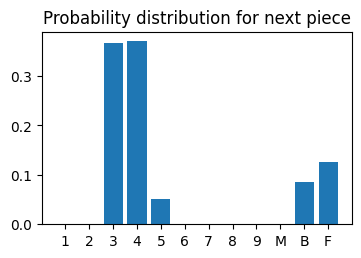

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B, 6, B, 3, 4, 3, 5, 6
3, 5, B, 4


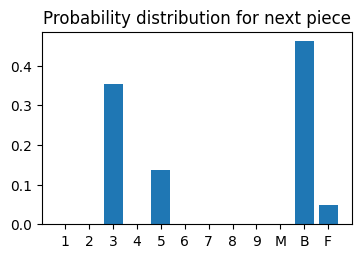

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B, 6, B, 3, 4, 3, 5, 6
3, 5, B, 4, B


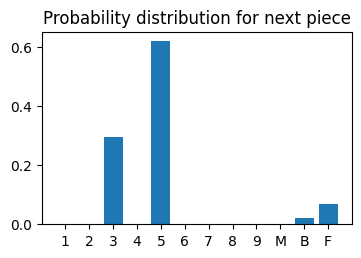

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B, 6, B, 3, 4, 3, 5, 6
3, 5, B, 4, B, 5


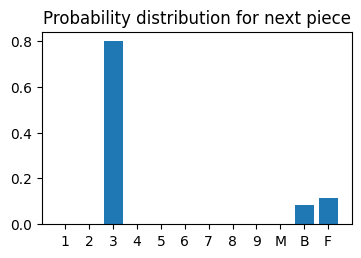

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B, 6, B, 3, 4, 3, 5, 6
3, 5, B, 4, B, 5, 3


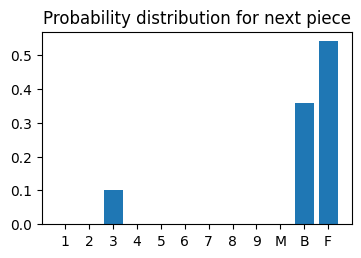

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B, 6, B, 3, 4, 3, 5, 6
3, 5, B, 4, B, 5, 3, F


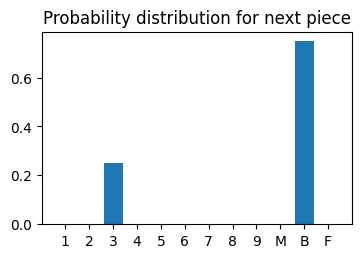

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B, 6, B, 3, 4, 3, 5, 6
3, 5, B, 4, B, 5, 3, F, 3


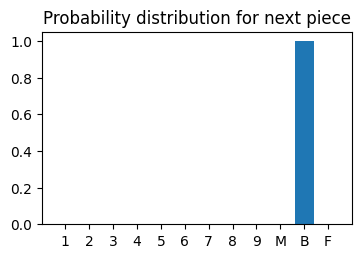

_  _  x  x  _  _  x  x  _  _
2, 2, 6, 4, 2, 6, 1, 8, 5, 2
2, 7, 8, 2, 7, 9, 2, M, 2, 7
4, B, B, 6, B, 3, 4, 3, 5, 6
3, 5, B, 4, B, 5, 3, F, 3, B


In [ ]:
setup, distributions = generate_setup(model)
for i in range(40):
    print_setup(setup[:i+1])
    plt.figure(figsize=(4, 2.5))
    plt.title("Probability distribution for next piece")
    plt.bar(HUMAN_READABLE.values(), distributions[i].detach())
    plt.show()
print_setup(setup)